<a href="https://colab.research.google.com/github/Carlos-G-Santos/bh14/blob/main/plot_artigo_dose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path1 = "/content/drive/MyDrive/validação/energy.txt"
file_path2 = "/content/drive/MyDrive/validação/fatores.txt"


In [5]:
def data(file_path_x, file_path_y):
  with open(file_path_x, "r") as file_x, open(file_path_y, "r") as file_y:
    lines_x = file_x.readlines()
    lines_y = file_y.readlines()
  x_data = [line.strip().split() for line in lines_x]
  y_data = [line.strip().split() for line in lines_y]
  x_df = pd.DataFrame(x_data)
  y_df = pd.DataFrame(y_data)
  x_df = x_df.replace("None", np.nan).apply(pd.to_numeric, errors="coerce")
  y_df = y_df.replace("None", np.nan).apply(pd.to_numeric, errors="coerce")
  x_stacked = x_df.stack().reset_index(drop=True)
  y_stacked = y_df.stack().reset_index(drop=True)
  x_df = x_stacked.dropna().to_frame(name= "Energy (MeV)")
  y_df = y_stacked.dropna().to_frame(name= "H*(10)")
  data_df = pd.concat([x_df,y_df], axis=1)

  return data_df


Text(0, 0.5, 'Conversion Factor (mrem/hr per n/cm²s)')

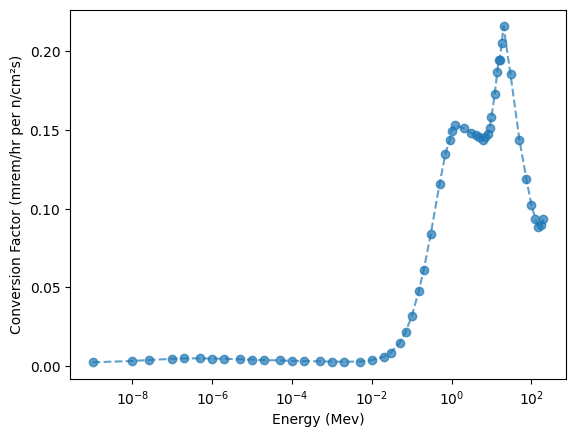

In [6]:
df = data(file_path1, file_path2)

# ICRP-74 Flux-to-Dose Equivalent Rate
fig, ax= plt.subplots()

# valores de x e y
ax.plot(df["Energy (MeV)"], df["H*(10)"], linestyle='--', marker='o',
        alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel("Energy (Mev)")
ax.set_ylabel("Conversion Factor (mrem/hr per n/cm²s)")

In [7]:
from scipy import integrate
from scipy.integrate import trapezoid
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import simpson

# integral

In [8]:
# Extrair os dados como arrays numpy
x_values = df["Energy (MeV)"].values
y_values = df["H*(10)"].values

# Calcular a integral usando a regra do trapézio com numpy
integral_trapz = trapezoid(y_values, x_values)
integral_value = simpson(y_values, x_values)

print(f"Integral (Regra do Trapézio): {integral_trapz}")
print(f"Integral using Simpson's rule: {integral_value}")

Integral (Regra do Trapézio): 24.027156779906832
Integral using Simpson's rule: 23.920575385531183


/tmp/ipython-input-173940392.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_trapz.plot(x_values, y_values, 'o-', linestyle='--', color='red', markersize=4, label='Pontos de Dados')


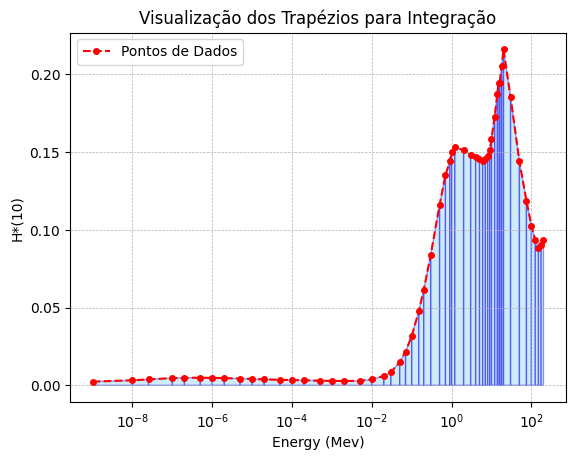

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Extrair os dados como arrays numpy
x_values = df["Energy (MeV)"].values
y_values = df["H*(10)"].values

# Criar um novo gráfico para visualizar os trapézios
fig_trapz, ax_trapz = plt.subplots()

# Adicionar os trapézios ao gráfico
for i in range(len(x_values) - 1):
    x = [x_values[i], x_values[i], x_values[i+1], x_values[i+1]]
    y = [0, y_values[i], y_values[i+1], 0]
    poly = Polygon(list(zip(x, y)), closed=True, facecolor='skyblue', alpha=0.4, edgecolor='blue')
    ax_trapz.add_patch(poly)

# Opcional: plotar os pontos originais no gráfico dos trapézios para referência
ax_trapz.plot(x_values, y_values, 'o-', linestyle='--', color='red', markersize=4, label='Pontos de Dados')


ax_trapz.set_xscale('log')
ax_trapz.set_xlabel("Energy (Mev)")
ax_trapz.set_ylabel("H*(10)")
ax_trapz.set_title("Visualização dos Trapézios para Integração")
ax_trapz.grid(True, which="both", linestyle='--', linewidth=0.5)
ax_trapz.legend()

plt.show()

In [1]:
def div_range(x_values, y_values):
  # func para separar os dados em faixas de energia:
  term = []
  ep = []
  fast =[]

  for i in range(len(df)):
    if x_values[i] <= 5e-7:
      term.append(y_values[i])
    elif 5e-7 < x_values[i] <= 0.5:
      ep.append(y_values[i])
    elif 3 <  x_values[i] <= 11:
      fast.append(y_values[i])
    else:
      pass

  e_term = pd.DataFrame([x for x in x_values if x <= 5e-7], columns=["Energy (MeV)"])
  e_ep = pd.DataFrame([x for x in x_values if 5e-7 < x <= 0.5], columns=["Energy (MeV)"])
  e_fast =pd.DataFrame([x for x in x_values if 3 < x <= 11], columns=["Energy (MeV)"])

  # tirando dados valores faltantes
  e_term = e_term.dropna()
  e_ep = e_ep.dropna()
  e_fast = e_fast.dropna()
  # transformando em DF os valores de y e add coluna
  term_df = pd.DataFrame(term, columns=["H*(10)"])
  ep_df = pd.DataFrame(ep, columns=["H*(10)"])
  fast_df = pd.DataFrame(fast, columns=["H*(10)"])
  # juntando os dados x e y (concat)
  data_term = pd.concat([e_term, term_df], axis=1)
  data_ep = pd.concat([e_ep, ep_df], axis=1)
  data_fast = pd.concat([e_fast, fast_df], axis=1)

  return data_term, data_ep, data_fast

In [10]:
data_term, data_ep, data_fast = div_range(x_values, y_values)


In [11]:
# Extrair os dados como arrays numpy
x_term = data_term["Energy (MeV)"].values
y_term = data_term["H*(10)"].values

x_ep = data_ep["Energy (MeV)"].values
y_ep = data_ep["H*(10)"].values

x_fast = data_fast["Energy (MeV)"].values
y_fast = data_fast["H*(10)"].values

# Calcular a integral usando a regra do trapézio com numpy
int_trapz_term = trapezoid(y_term, x_term)
int_simp_term = simpson(y_term, x_term)

int_trapz_ep = trapezoid(y_ep, x_ep)
int_simp_ep = simpson(y_ep, x_ep)

int_trapz_fast = trapezoid(y_fast, x_fast)
int_simp_fast = simpson(y_fast, x_fast)

print(f"Integral (Regra do Trapézio): {int_trapz_term} mRem/hr per flux")
print(f"Integral (Regra de simpson): {int_simp_term} mRem/hr per flux")
print()
print(f"Integral (Regra do Trapézio): {int_trapz_ep} mRem/hr per flux")
print(f"Integral (Regra de simpson): {int_simp_ep} mRem/hr per flux")
print()
print(f"Integral (Regra do Trapézio): {int_trapz_fast} mRem/hr per flux")
print(f"Integral (Regra de simpson): {int_simp_fast} mRem/hr per flux")

Integral (Regra do Trapézio): 2.3338314e-09 mRem/hr per flux
Integral (Regra de simpson): 2.3705694678882115e-09 mRem/hr per flux

Integral (Regra do Trapézio): 0.033480775152 mRem/hr per flux
Integral (Regra de simpson): 0.033838457675 mRem/hr per flux

Integral (Regra do Trapézio): 0.8866800000000001 mRem/hr per flux
Integral (Regra de simpson): 0.88632 mRem/hr per flux


In [12]:
flux =[8.58*10**6, 4.87*10**5 ,1.82*10**6]

In [13]:
dose = flux[0]*int_trapz_term + flux[1]*int_trapz_ep + flux[2]*int_trapz_fast
print(f"{dose} mRem/hr")
print(f"{dose*10**-5} Sv/hr")

1630062.7575232978 mRem/hr
16.30062757523298 Sv/hr
